# Portfolio Analyzer

In [2]:
library(ggplot2)
library(dplyr)
library(scales)

In [3]:
stock_ticker  <- "MSTR"
market_ticker <- "SCHB"
stock_df  <- read.csv(sprintf("../../../data/%s.Daily.csv",  stock_ticker))
market_df <- read.csv(sprintf("../../../data/%s.Daily.csv", market_ticker))
stock_df$ret  <- c(NA, diff(stock_df$close)  / head(stock_df$close, -1))
market_df$ret <- c(NA, diff(market_df$close) / head(market_df$close, -1))

In [4]:
portfolio <- merge(market_df[, c("timestamp","close","ret")],
                   stock_df[,  c("timestamp","close","ret")],
                   by = "timestamp", suffixes = c("_market","_risky"))
colnames(portfolio) <- c("timestamp","market_close","market_ret",
                          "risky_asset_close","risky_asset_ret")
portfolio$timestamp <- as.Date(portfolio$timestamp)

In [5]:
last_year <- tail(portfolio, 252)

In [6]:
head(portfolio)

,timestamp,market_close,market_ret,risky_asset_close,risky_asset_ret
,<date>,<dbl>,<dbl>,<dbl>,<dbl>
1,2020-12-28,15.12,0.0046512,37.00,NA
2,2020-12-29,15.07,-0.0033069,36.61,-0.0105405
3,2020-12-30,15.11,0.0026543,39.00,0.0652827
4,2020-12-31,15.17,0.0039709,38.86,-0.0035897
5,2021-01-04,14.96,-0.0138431,42.52,0.0941843
6,2021-01-05,15.08,0.0080214,42.86,0.0079962


## Efficient Frontier - Annualised View

In [7]:
weights <- seq(0, 1, length.out = 100)
efficient_frontier <- data.frame(
    risky_asset_weight = weights,
    market_weight      = 1 - weights
)

market_return   <- mean(portfolio$market_ret,     na.rm = TRUE)
market_var      <- var(portfolio$market_ret,      na.rm = TRUE)
security_return <- mean(portfolio$risky_asset_ret, na.rm = TRUE)
security_var    <- var(portfolio$risky_asset_ret,  na.rm = TRUE)
covariance      <- cov(portfolio$market_ret, portfolio$risky_asset_ret, use="complete.obs")

efficient_frontier$portfolio_return <-
    (efficient_frontier$market_weight * market_return +
     efficient_frontier$risky_asset_weight * security_return) * 252

efficient_frontier$portfolio_vol <- sqrt(
    efficient_frontier$market_weight^2 * market_var +
    efficient_frontier$risky_asset_weight^2 * security_var +
    efficient_frontier$market_weight * efficient_frontier$risky_asset_weight * covariance
) * sqrt(252)

efficient_frontier$sharpe_ratio <- efficient_frontier$portfolio_return / efficient_frontier$portfolio_vol

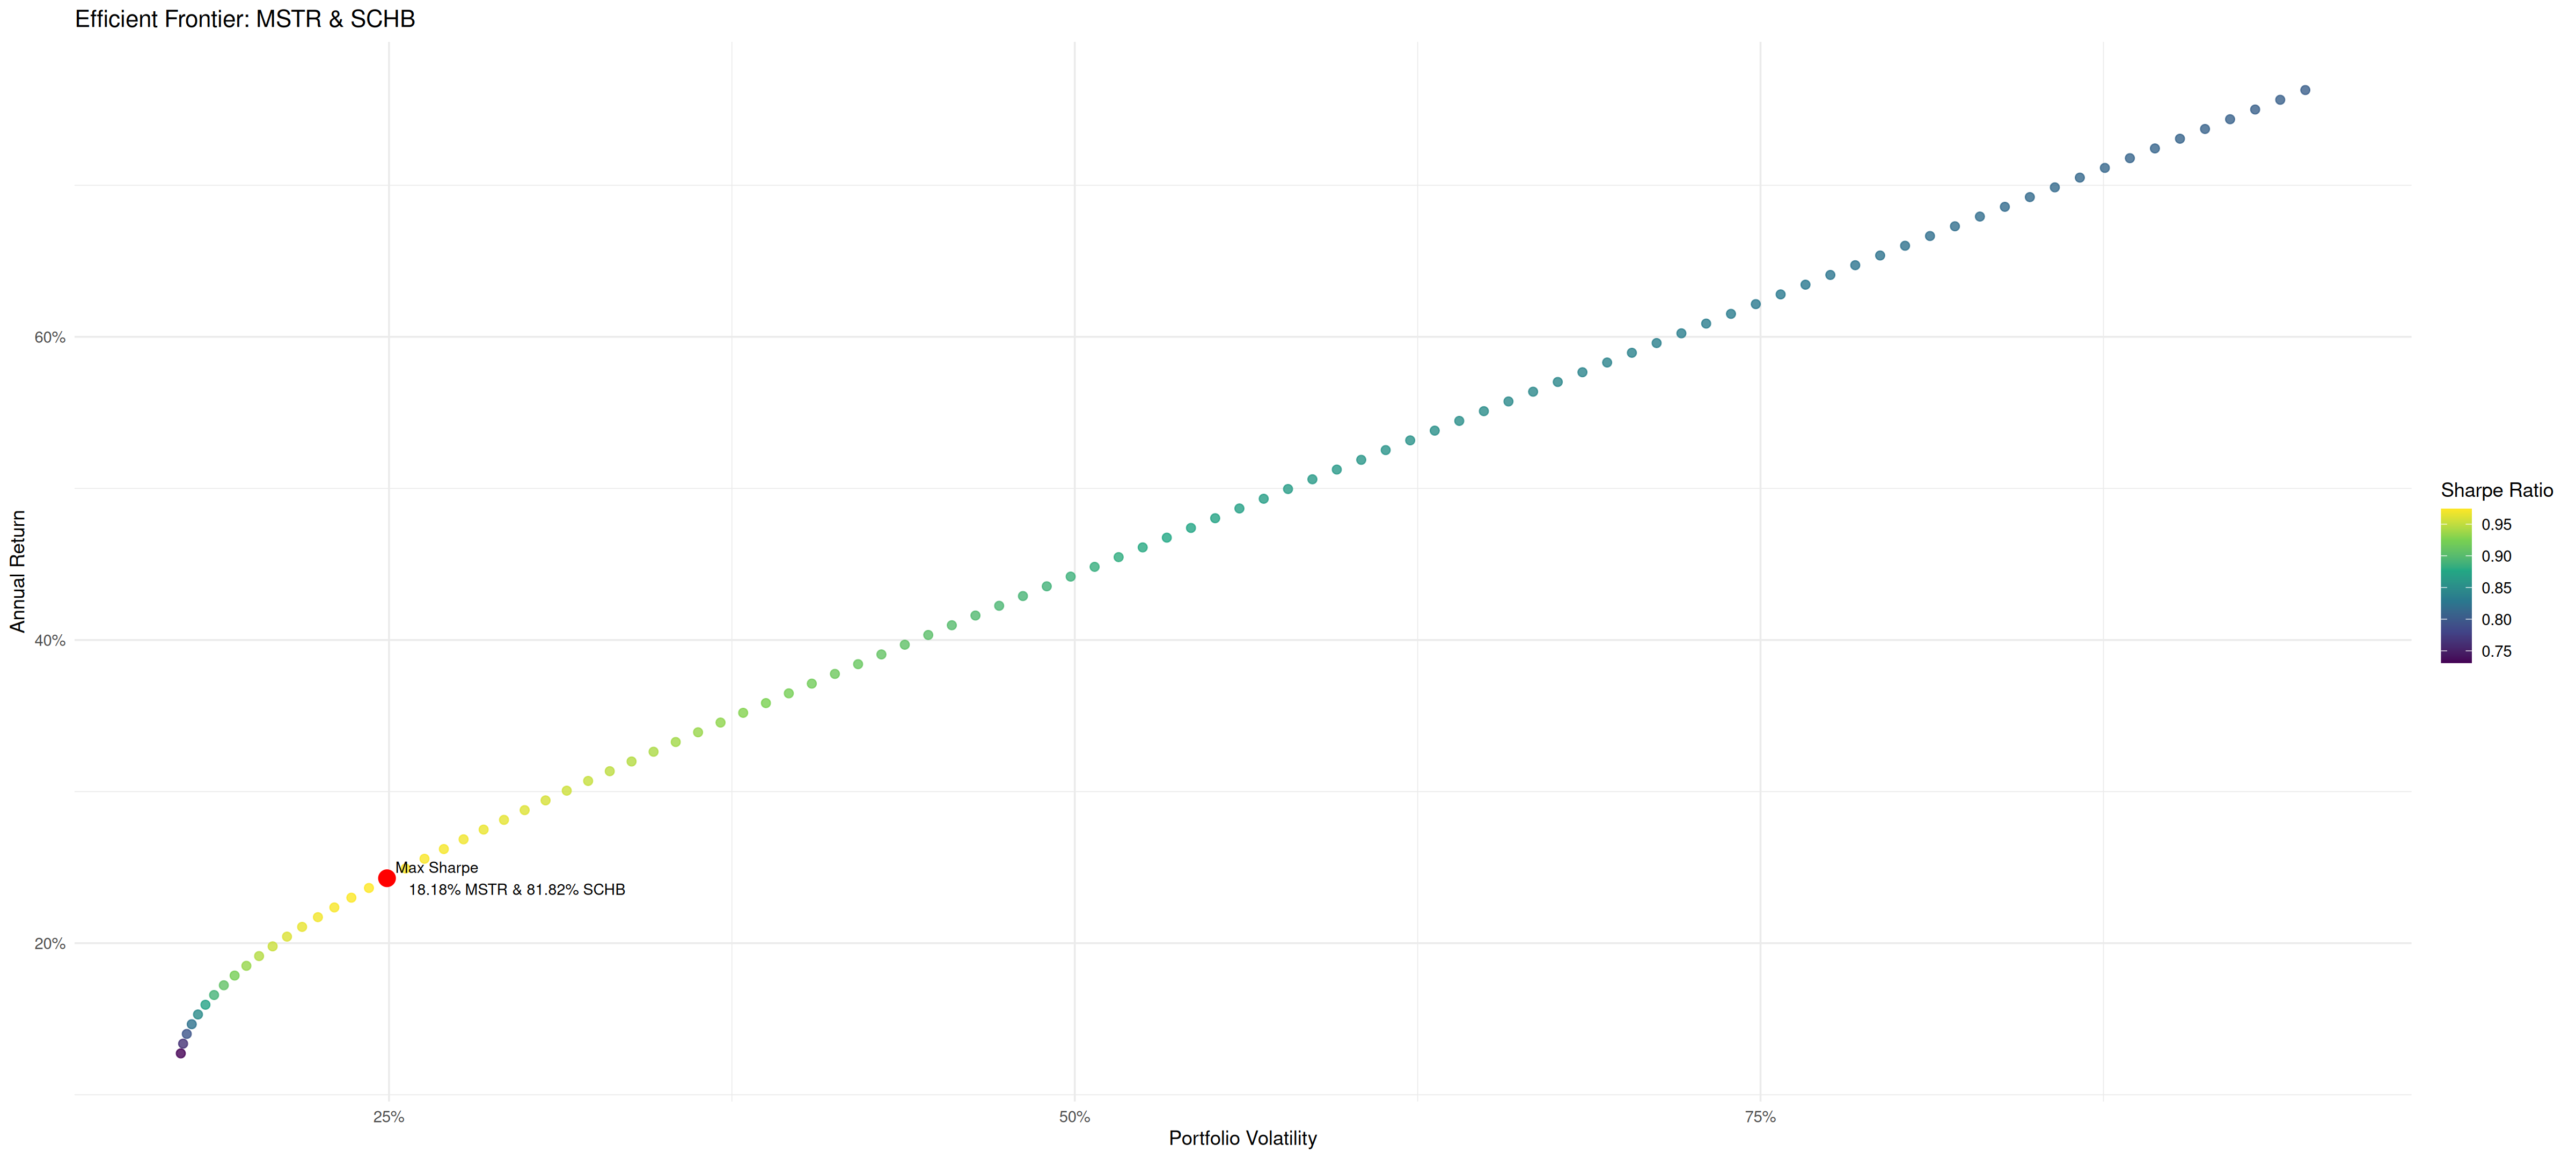

In [8]:
best_idx        <- which.max(efficient_frontier$sharpe_ratio)
best_risky_wt   <- efficient_frontier$risky_asset_weight[best_idx]
best_market_wt  <- efficient_frontier$market_weight[best_idx]

ggplot(efficient_frontier, aes(x = portfolio_vol, y = portfolio_return, colour = sharpe_ratio)) +
    geom_point(size = 2, alpha = 0.8) +
    scale_colour_viridis_c(name = "Sharpe Ratio") +
    geom_point(data = efficient_frontier[best_idx, ],
               aes(x = portfolio_vol, y = portfolio_return), colour="red", size=4) +
    annotate("text",
             x = efficient_frontier$portfolio_vol[best_idx],
             y = efficient_frontier$portfolio_return[best_idx],
             label = sprintf("Max Sharpe
%.2f%% %s & %.2f%% %s",
                             best_risky_wt*100, stock_ticker,
                             best_market_wt*100, market_ticker),
             hjust = -0.1, size = 3) +
    scale_x_continuous(labels = percent_format()) +
    scale_y_continuous(labels = percent_format()) +
    labs(title  = sprintf("Efficient Frontier: %s & %s", stock_ticker, market_ticker),
         x = "Portfolio Volatility", y = "Annual Return") +
    theme_minimal()

## Backtest - Optimised Portfolio

In [9]:
calculate_efficient_frontier <- function(returns_df, stock_col, market_col) {
    weights <- seq(0, 1, length.out = 250)
    ef      <- data.frame(risky_asset_weight = weights, market_weight = 1 - weights)

    mr  <- mean(returns_df[[market_col]],  na.rm=TRUE)
    mv  <- var(returns_df[[market_col]],   na.rm=TRUE)
    sr  <- mean(returns_df[[stock_col]],   na.rm=TRUE)
    sv  <- var(returns_df[[stock_col]],    na.rm=TRUE)
    cov_val <- cov(returns_df[[market_col]], returns_df[[stock_col]], use="complete.obs")

    ef$portfolio_return <- (ef$market_weight*mr + ef$risky_asset_weight*sr) * 252
    ef$portfolio_vol    <- sqrt(ef$market_weight^2*mv + ef$risky_asset_weight^2*sv +
                                ef$market_weight*ef$risky_asset_weight*cov_val) * sqrt(252)
    ef$sharpe_ratio     <- ef$portfolio_return / ef$portfolio_vol
    best <- ef[which.max(ef$sharpe_ratio), c("risky_asset_weight","market_weight")]
    list(optimal_weights = as.numeric(best), ef = ef)
}

In [10]:
run_backtest <- function(prices, returns, risky_col, etf_col,
                           initial_capital = 100000, rebalance_interval = 5) {
    portfolio_value <- initial_capital
    holdings_risky  <- 0; holdings_etf <- 0
    pv_list <- numeric(nrow(returns)); dates <- rownames(returns)

    result <- calculate_efficient_frontier(returns[1:min(252, nrow(returns)), ], risky_col, etf_col)
    w_risky <- result$optimal_weights[1]
    w_etf   <- result$optimal_weights[2]

    cat(sprintf("Starting backtest. Initial capital: $%.2f\n", initial_capital))

    for (i in seq_len(nrow(returns))) {
        if (i == 1 || i %% rebalance_interval == 0) {
            lookback <- returns[max(1, i-252):(i-1), , drop=FALSE]
            if (nrow(lookback) > 10) {
                res     <- calculate_efficient_frontier(lookback, risky_col, etf_col)
                w_risky <- res$optimal_weights[1]
                w_etf   <- res$optimal_weights[2]
            }
            risky_price    <- prices[i, risky_col]
            etf_price      <- prices[i, etf_col]
            holdings_risky <- (portfolio_value * w_risky) / risky_price
            holdings_etf   <- (portfolio_value * w_etf)   / etf_price
        }
        holdings_risky <- holdings_risky * (1 + returns[i, risky_col])
        holdings_etf   <- holdings_etf   * (1 + returns[i, etf_col])
        portfolio_value <- holdings_risky * prices[i, risky_col] +
                           holdings_etf   * prices[i, etf_col]
        pv_list[i] <- portfolio_value
    }
    cat(sprintf("Final Portfolio Value: $%.2f\n", tail(pv_list,1)))
    pv_list
}

In [11]:
# Prepare aligned price and return data frames
tempA <- merge(stock_df[,c("timestamp","close")],
               market_df[,c("timestamp","close")],
               by="timestamp", suffixes=c("_risky","_market"))
tempA$timestamp <- as.Date(tempA$timestamp)
rownames(tempA) <- as.character(tempA$timestamp)
tempA$timestamp <- NULL
colnames(tempA) <- c(stock_ticker, market_ticker)

tempB <- merge(stock_df[,c("timestamp","ret")],
               market_df[,c("timestamp","ret")],
               by="timestamp", suffixes=c("_risky","_market"))
tempB$timestamp <- as.Date(tempB$timestamp)
rownames(tempB) <- as.character(tempB$timestamp)
tempB$timestamp <- NULL
colnames(tempB) <- c(stock_ticker, market_ticker)
tempB <- na.omit(tempB)

In [12]:
pv <- run_backtest(tempA[rownames(tempB), ], tempB,
                   stock_ticker, market_ticker,
                   initial_capital=100000, rebalance_interval=5)

Starting backtest. Initial capital: $100000.00
Final Portfolio Value: $2653160.67


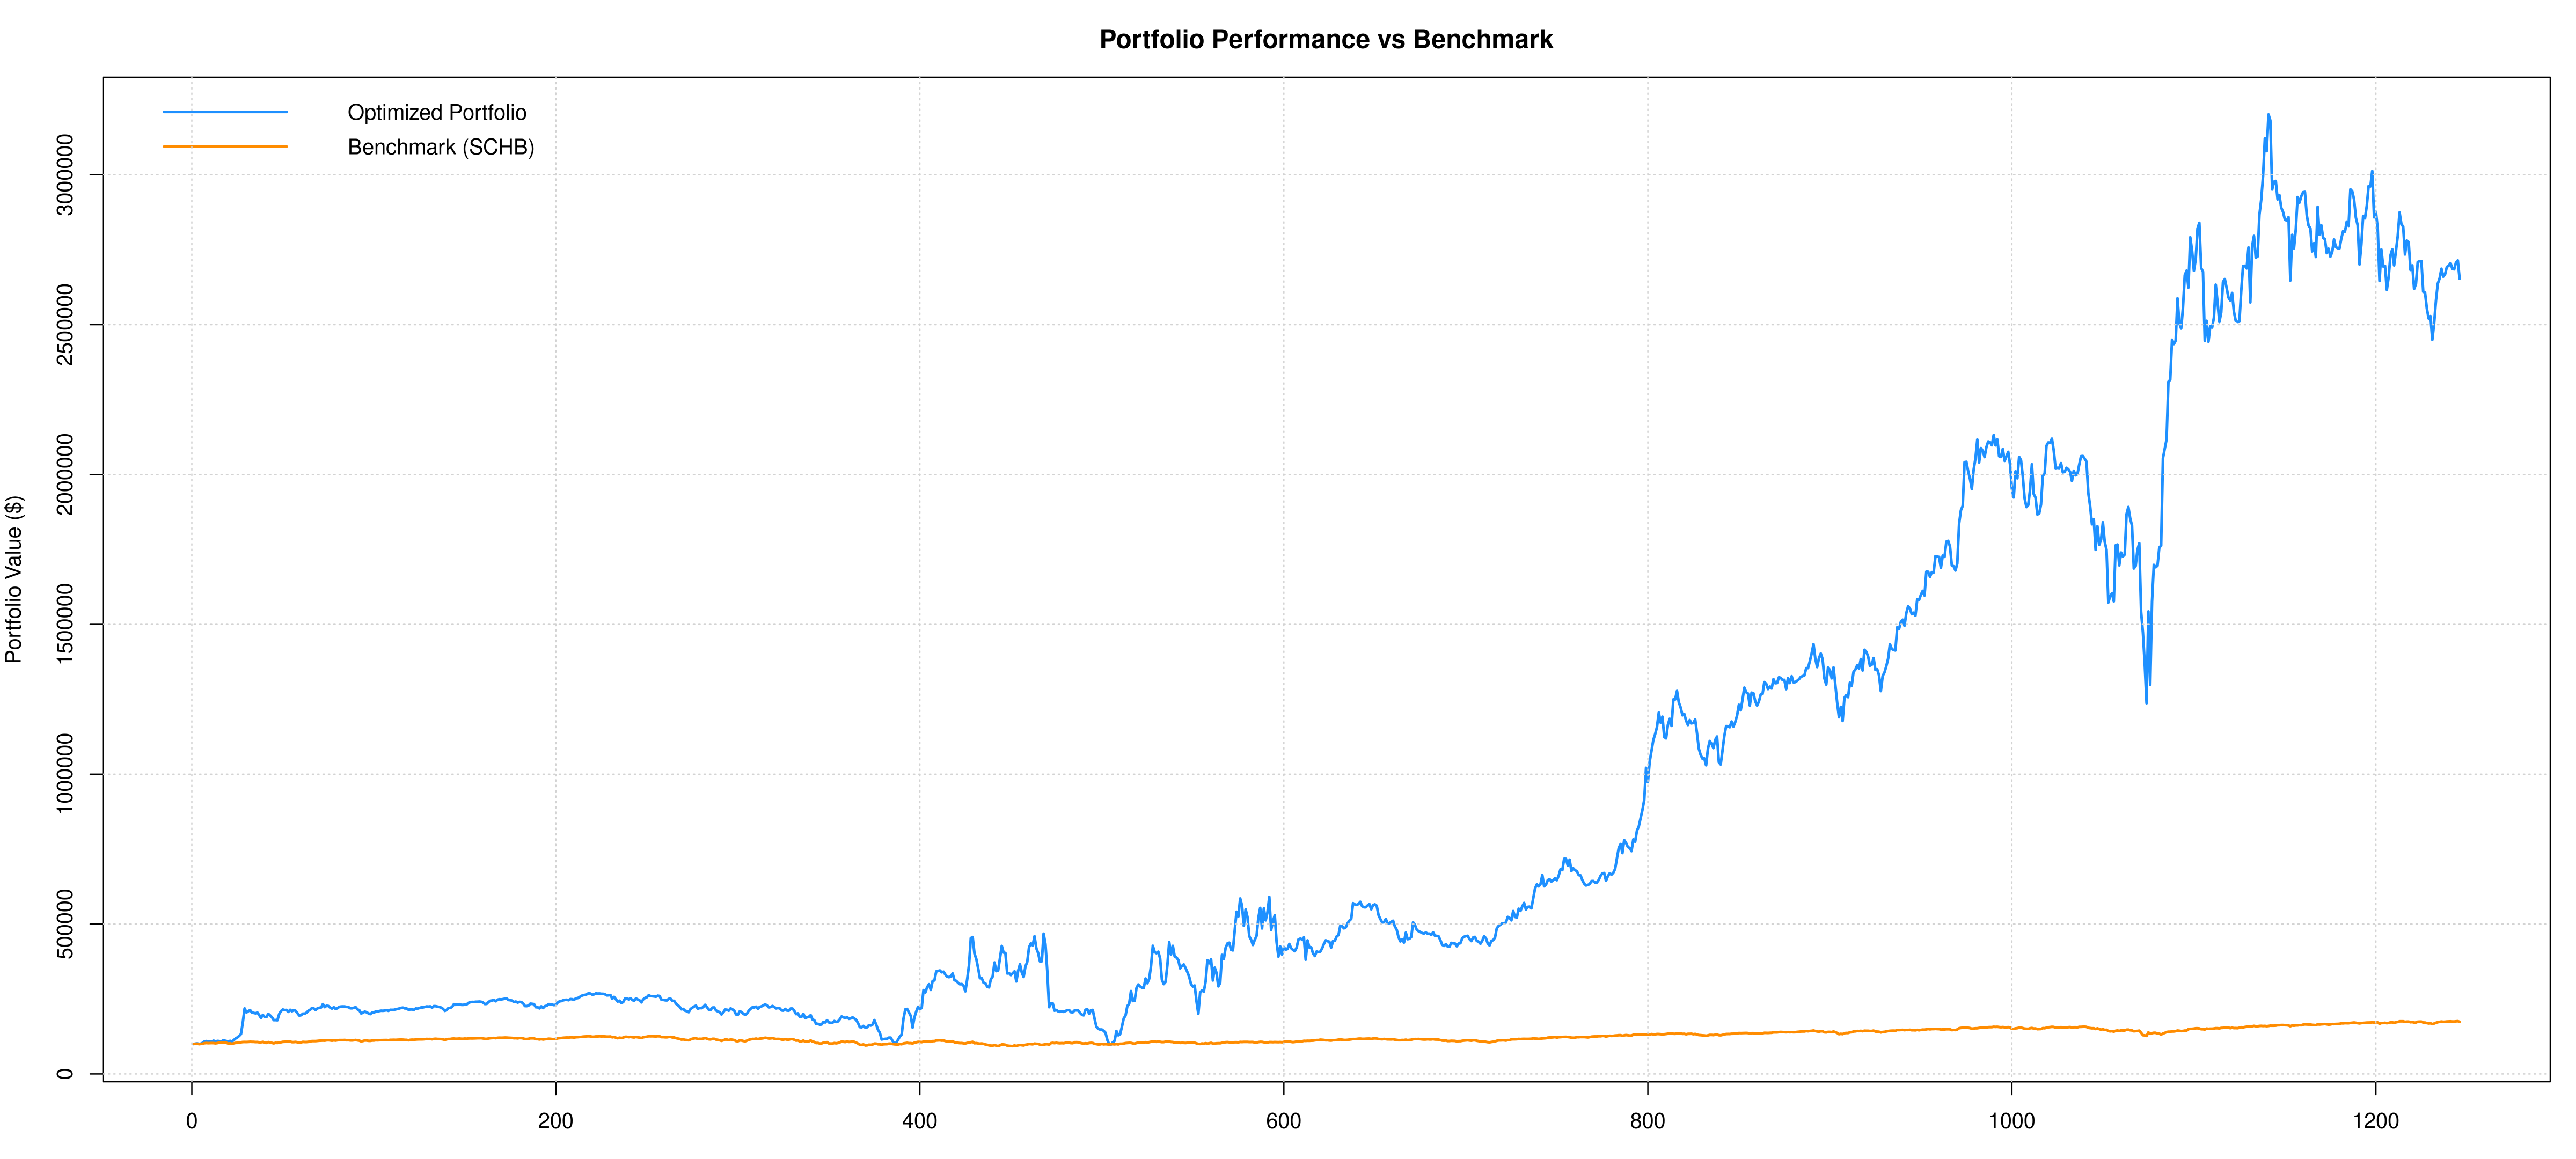

In [13]:
# Benchmark: buy-and-hold market ETF
dates_idx <- rownames(tempB)
etf_prices <- tempA[dates_idx, market_ticker]
benchmark  <- (etf_prices / etf_prices[1]) * 100000

par(mar=c(3,4,3,1))
plot(seq_along(pv), pv, type="l", col="dodgerblue", lwd=2,
     main="Portfolio Performance vs Benchmark",
     xlab="", ylab="Portfolio Value ($)")
lines(seq_along(benchmark), benchmark, col="darkorange", lwd=2)
legend("topleft", legend=c("Optimized Portfolio",sprintf("Benchmark (%s)", market_ticker)),
       col=c("dodgerblue","darkorange"), lwd=2, bty="n")
grid()

## This is a naive model where it's rebalancing daily but that's not how it's done in the industry. 
## Here are some of the ways it can be improved
- Create a switch to rebalance daily or weekly
- If weekly then select a particular day of the week
- Rebalance based on volatlity threshold
- Rebalance based on correlation